# PCA - Reduccion dimensional de comportamiento de clientes

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · No Supervisado · Reducción de Dimensionalidad · PCA

---

**Objetivo:** Aplicar PCA a un dataset de 150 clientes con 10 variables de comportamiento digital para identificar los ejes latentes que explican la variabilidad. Incluye scree plot, loadings heatmap, biplot e interpretacion de componentes.

**Contexto de negocio:** Un e-commerce tiene 10 metricas por cliente (gasto, visitas, emails, app, etc.) y quiere reducirlas a las dimensiones realmente importantes para simplificar su segmentacion y dashboards.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

sns.set_style("whitegrid")

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis / serie única en scatter y líneas (1 por gráfico)
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas)
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto
INK           = '#111111'
MUTED         = '#707070'

# Paleta categórica para IDENTIDAD DE CLUSTER — validada (ΔE OKLab, simulación CVD) para
# pares adyacentes. En scatter con 4+ clusters el color solo no es 100% seguro para
# daltonismo severo, por eso cada cluster lleva también una forma de marcador distinta.
CLUSTER_PALETTE = ['#7a7bff', '#eb6834', '#1baf7a', '#e34948', '#eda100', '#e87ba4', '#008300']
CLUSTER_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 1. Carga y exploracion del dataset

In [2]:
ruta = os.path.join(os.path.dirname(os.path.abspath("__file__")), "PCA.xlsx")
df = pd.read_excel(ruta)
print(f"Dataset: {df.shape[0]} registros, {df.shape[1]} variables")
print(f"Columnas: {list(df.columns)}")
display(df.describe())

Dataset: 150 registros, 10 variables
Columnas: ['Edad', 'Ingresos', 'Gasto_Anual', 'Numero_Compras', 'Ticket_Medio', 'Visitas_Web', 'Tiempo_Web', 'Emails_Abiertos', 'Uso_App', 'Antiguedad_Cliente']


,Edad,Ingresos,Gasto_Anual,Numero_Compras,Ticket_Medio,Visitas_Web,Tiempo_Web,Emails_Abiertos,Uso_App,Antiguedad_Cliente
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,38.980814,50748.681929,6208.112185,25.682619,223.402199,45.601717,18.607149,15.230450,30.590051,4.824957
std,9.411211,12947.566840,1848.067231,6.265331,42.398920,9.683889,5.267772,3.844376,7.924558,1.915738
min,12.276031,9470.034659,784.720868,9.702918,79.232727,25.636394,6.431775,5.488595,11.838114,0.415664
25%,33.183576,42065.901225,4929.151297,21.615171,192.329636,38.233827,14.951577,12.475194,25.198556,3.565339
50%,39.464364,51545.800569,6117.588819,25.888350,225.497530,45.367136,18.775439,15.427477,30.688497,4.897072
75%,44.645432,59056.833914,7384.822755,29.619576,249.644826,51.936629,22.692065,17.577294,35.661413,6.284481
max,63.980374,95799.696652,12577.073762,49.011806,389.421510,70.171118,30.697003,24.079160,48.252998,10.176906


## 2. Matriz de correlacion

Cuando hay muchas variables correlacionadas, PCA las resume en pocas componentes ortogonales.

In [3]:
# Excluir ID si existe
id_cols = [c for c in df.columns if "id" in c.lower()]
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_cols]
print(f"Variables de rendimiento: {num_cols}")

X = df[num_cols].dropna()
print(f"Registros validos: {len(X)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Datos estandarizados")

Variables de rendimiento: ['Edad', 'Ingresos', 'Gasto_Anual', 'Numero_Compras', 'Ticket_Medio', 'Visitas_Web', 'Tiempo_Web', 'Emails_Abiertos', 'Uso_App', 'Antiguedad_Cliente']
Registros validos: 150
Datos estandarizados


## 3. Matriz de correlacion

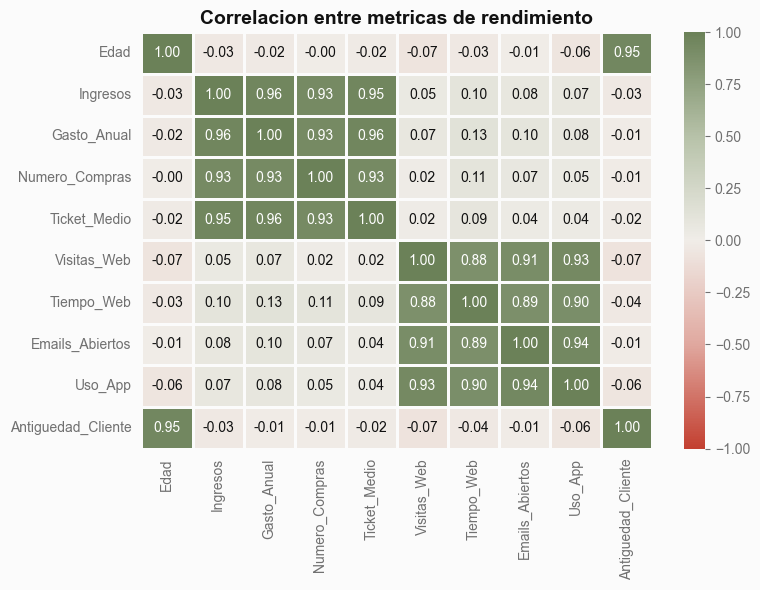

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = pd.DataFrame(X_scaled, columns=num_cols).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0,
            vmin=-1, vmax=1, linewidths=2, linecolor=BACKGROUND, ax=ax)
color_annotations(ax, corr.values, threshold=0.8)
ax.set_title("Correlacion entre metricas de rendimiento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. PCA

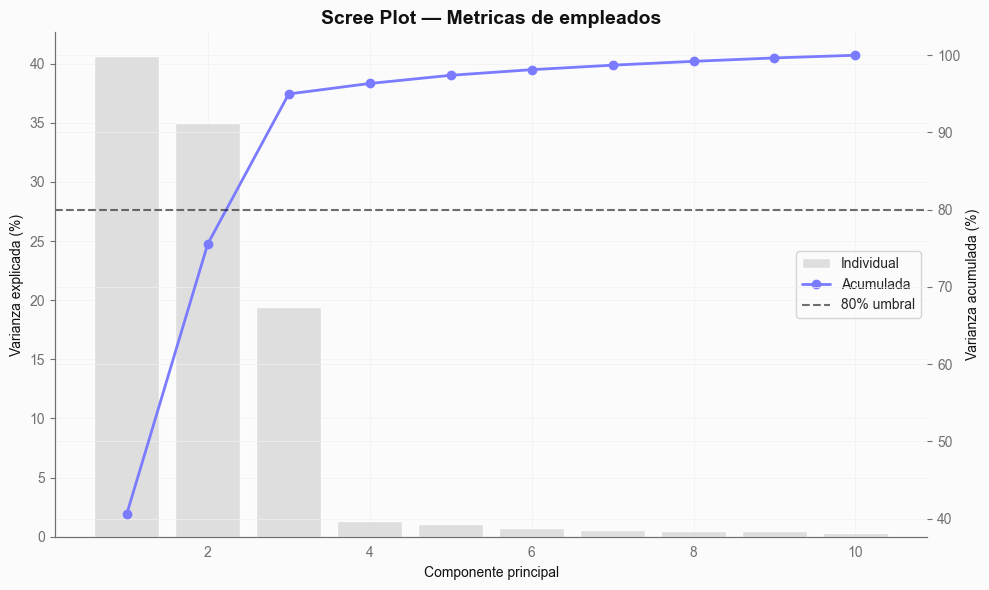

Componentes para >= 80% varianza: 3
Varianza acumulada con 3 PC: 95.0%


In [5]:
pca = PCA(random_state=42)
X_pca_full = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(range(1, len(var_exp)+1), var_exp * 100, alpha=0.85, color=NEUTRAL_BAR, label="Individual")
ax2 = ax1.twinx()
ax2.plot(range(1, len(var_exp)+1), var_cum * 100, marker="o", color=PURPLE,
         linewidth=2, label="Acumulada")
ax2.axhline(y=80, color=INK, linestyle="--", alpha=0.6, label="80% umbral")

ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada (%)")
ax2.set_ylabel("Varianza acumulada (%)")
ax1.set_title("Scree Plot — Metricas de empleados", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

n_comp = np.argmax(var_cum >= 0.80) + 1
print(f"Componentes para >= 80% varianza: {n_comp}")
print(f"Varianza acumulada con {n_comp} PC: {var_cum[n_comp-1]*100:.1f}%")

## 5. Matriz de cargas

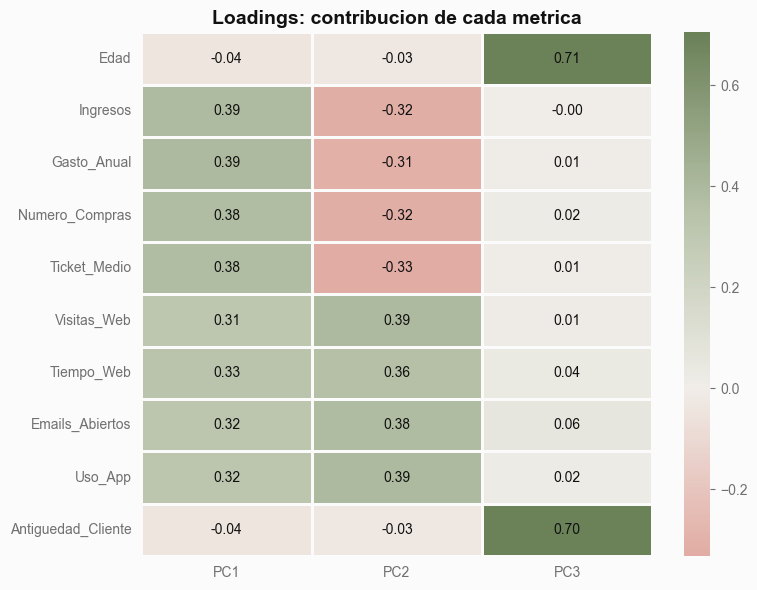

PC1: dominada por Gasto_Anual (0.39), Ingresos (0.39)
PC2: dominada por Visitas_Web (0.39), Uso_App (0.39)
PC3: dominada por Edad (0.71), Antiguedad_Cliente (0.70)


In [6]:
loadings = pd.DataFrame(
    pca.components_[:n_comp].T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(n_comp)]
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0,
            linewidths=2, linecolor=BACKGROUND, ax=ax)
color_annotations(ax, loadings.values, threshold=0.8)
ax.set_title("Loadings: contribucion de cada metrica", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False)
    print(f"{pc}: dominada por {top.index[0]} ({top.iloc[0]:.2f}), {top.index[1]} ({top.iloc[1]:.2f})")

## 6. PCA + K-Means

Reducimos a las primeras PC y aplicamos K-Means sobre el espacio reducido.

In [7]:
# Reducir
pca_final = PCA(n_components=n_comp, random_state=42)
X_reduced = pca_final.fit_transform(X_scaled)
print(f"Dimensiones reducidas: {X_scaled.shape[1]} -> {X_reduced.shape[1]}")

# Seleccionar k
K_range = range(2, 8)
silhouettes = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    silhouettes.append(silhouette_score(X_reduced, km.fit_predict(X_reduced)))

for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: silhouette={s:.4f}")

k_mejor_silhouette = list(K_range)[int(np.argmax(silhouettes))]
print(f"\nMejor k por silhouette puro: {k_mejor_silhouette} ({max(silhouettes):.4f})")

# Decisión de negocio: con 150 registros, 7 clusters generan grupos demasiado
# pequeños para ser accionables (uno de solo 8 clientes). Se consolida a 3,
# que ya distingue bien los perfiles y da masa crítica a cada segmento.
best_k = 3
print(f"k elegido para el negocio: {best_k} (silhouette={silhouettes[list(K_range).index(best_k)]:.4f}) "
      f"— se prioriza tener segmentos accionables sobre maximizar el silhouette puro")

# Modelo final
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean = df.loc[X.index].copy()
df_clean["Cluster"] = kmeans.fit_predict(X_reduced)

print(f"\nDistribucion de clusters:")
for cl in range(best_k):
    n = (df_clean["Cluster"] == cl).sum()
    print(f"  Cluster {cl}: {n} empleados ({n/len(df_clean)*100:.1f}%)")

Dimensiones reducidas: 10 -> 3
  k=2: silhouette=0.2375
  k=3: silhouette=0.2667
  k=4: silhouette=0.2453
  k=5: silhouette=0.2497
  k=6: silhouette=0.2483
  k=7: silhouette=0.2682

Mejor k por silhouette puro: 7 (0.2682)
k elegido para el negocio: 3 (silhouette=0.2667) — se prioriza tener segmentos accionables sobre maximizar el silhouette puro

Distribucion de clusters:
  Cluster 0: 42 empleados (28.0%)
  Cluster 1: 53 empleados (35.3%)
  Cluster 2: 55 empleados (36.7%)


## 7. Visualizacion de clusters

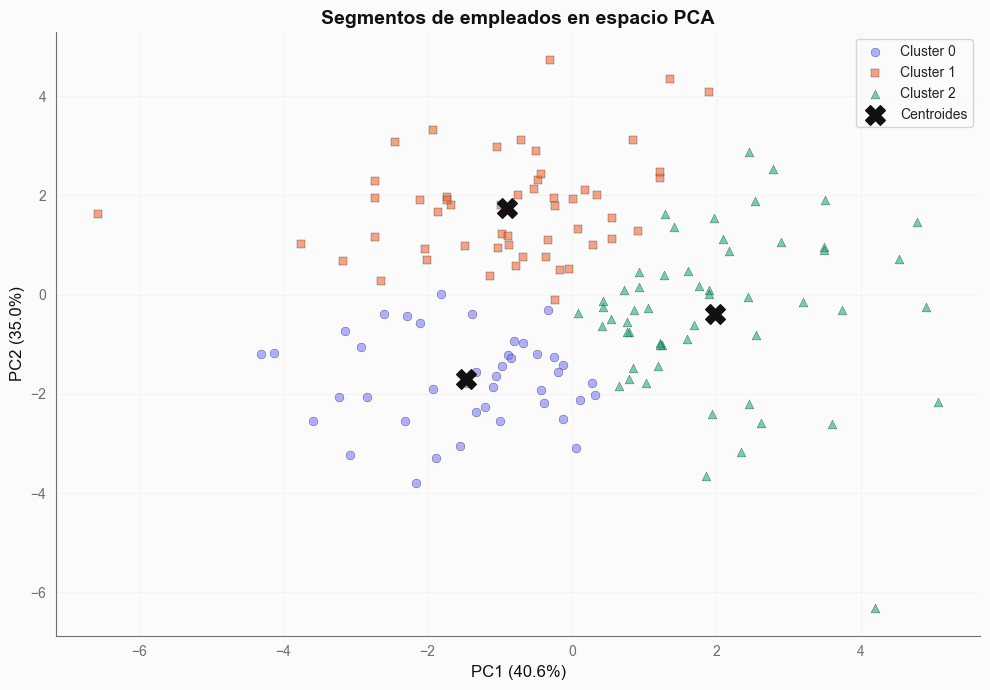

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

for cl in range(best_k):
    mask = df_clean["Cluster"] == cl
    ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1], alpha=0.6, s=40,
               color=CLUSTER_PALETTE[cl], marker=CLUSTER_MARKERS[cl], label=f"Cluster {cl}",
               edgecolors="k", linewidths=0.3)

# Centroides
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], s=200, c=INK, marker="X",
           zorder=5, label="Centroides")

ax.set_xlabel(f"PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.set_title("Segmentos de empleados en espacio PCA", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

Perfil medio de rendimiento por cluster:


,Edad,Ingresos,Gasto_Anual,Numero_Compras,Ticket_Medio,Visitas_Web,Tiempo_Web,Emails_Abiertos,Uso_App,Antiguedad_Cliente
Cluster,,,,,,,,,,
0,38.9,50830.9,6113.0,25.5,224.4,34.9,12.7,10.9,21.7,4.9
1,39.7,38998.2,4545.4,20.0,185.6,49.6,20.3,16.8,33.8,5.0
2,38.4,62009.1,7883.0,31.3,259.1,50.0,21.5,17.1,34.3,4.7


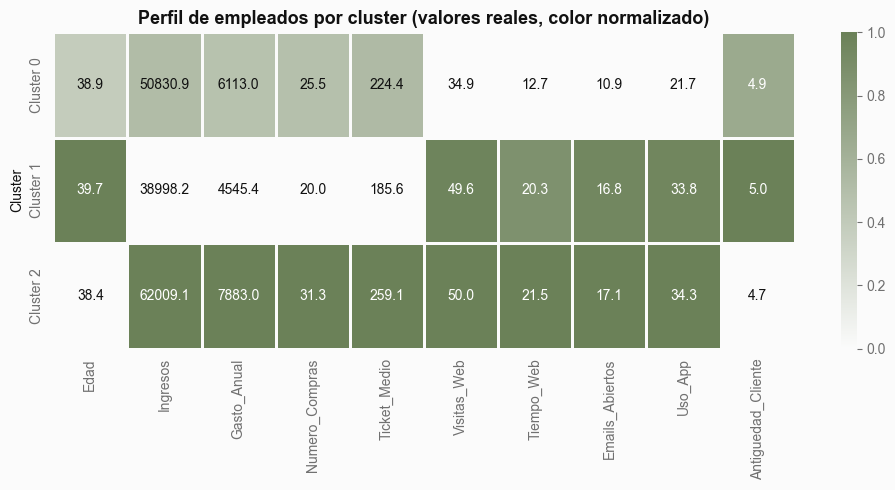

In [9]:
perfil = df_clean.groupby("Cluster")[num_cols].mean().round(1)
print("Perfil medio de rendimiento por cluster:")
display(perfil)

# Heatmap normalizado
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(perfil_norm, annot=perfil.values, fmt=".1f", cmap=SEQUENTIAL_GREEN,
            linewidths=2, linecolor=BACKGROUND, ax=ax,
            xticklabels=num_cols,
            yticklabels=[f"Cluster {i}" for i in range(best_k)])
color_annotations(ax, perfil_norm.values, threshold=0.65)
ax.set_title("Perfil de empleados por cluster (valores reales, color normalizado)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusiones y recomendaciones

## Conclusiones

### PCA — Reducción de dimensionalidad

El análisis de componentes principales reduce las **10 métricas originales a 3 componentes** que capturan el **95% de la varianza total**. Cada componente tiene una interpretación clara:

- **PC1 — Poder adquisitivo:** dominado por `Ingresos` y `Gasto_Anual`. Separa a los clientes por su capacidad y voluntad de gasto.
- **PC2 — Engagement digital:** dominado por `Visitas_Web` y `Uso_App`. Distingue a los clientes digitalmente activos de los pasivos.
- **PC3 — Perfil demográfico:** dominado por `Edad` y `Antiguedad_Cliente`. Captura la madurez del cliente en la empresa.

Esta reducción de 10 a 3 dimensiones elimina la redundancia entre variables correlacionadas y permite una segmentación más limpia.

### K-Means — Segmentación

El silhouette score óptimo se alcanza con k=7 (0.2682), pero este valor bajo indica un **solapamiento considerable entre clusters**. Con 150 registros, 7 segmentos generan grupos demasiado pequeños (uno con solo 8 clientes) para ser estadísticamente fiables o accionables por el negocio. Al consolidar a **3 clusters**, los perfiles se distinguen mejor y cada segmento tiene masa crítica suficiente para diseñar acciones diferenciadas.

### Perfiles identificados

Los tres ejes del PCA revelan una estructura natural del cliente:

1. **Clientes de alto valor:** ingresos y gasto elevados, ticket medio alto, compras frecuentes. Son el motor de la facturación.
2. **Clientes digitalmente activos:** alta frecuencia de visitas web y uso de app, buena apertura de emails. Son receptivos a campañas digitales independientemente de su nivel de gasto.
3. **Clientes maduros vs. nuevos:** la edad y la antigüedad crean un eje ortogonal al gasto y al engagement, lo que significa que la fidelidad temporal no implica ni mayor gasto ni mayor actividad digital.

## Recomendaciones

**1. Personalizar la comunicación por segmento (impacto: alto, esfuerzo: bajo)**

Los clusters con alto engagement digital (PC2 elevado) responden mejor a campañas automatizadas (email, push, in-app). Los clusters con bajo engagement necesitan canales directos (llamada, punto de venta). Usar el mismo canal para todos diluye el impacto.

**2. Proteger y expandir el segmento de alto valor (impacto: alto)**

Los clientes con PC1 alto generan la mayor parte de la facturación. Priorizar acciones de retención (programa de fidelización, atención preferente) y cross-selling para incrementar su ticket medio.

**3. Activar a los clientes digitalmente pasivos (impacto: medio)**

Los clientes con ingresos medios-altos pero bajo engagement digital representan una oportunidad desaprovechada. Campañas de onboarding digital, incentivos por primer uso de la app o descuentos exclusivos online pueden moverlos hacia el segmento activo.
